# Análisis Black–Scholes — Opciones Europeas
**Proyecto / Práctica**

**Integrantes:**  
- Mateo Gael Figueroa  
- Nataly Ramirez Machicado  
- Ostin Lizandro Colque  
- Josue Camacho Canaviri  

**Resumen:**  
Este notebook implementa el modelo de Black–Scholes para opciones europeas (call y put), calcula las griegas básicas (Delta, Vega) y genera visualizaciones: precios vs strike, decaimiento temporal del call ATM, griegas vs strike y superficies 3D de precio en función de strike y tiempo. Los parámetros usados son un ejemplo basado en datos de mercado (S₀ y σ podrían provenir de datos históricos), pero en este notebook se usan como entradas fijas para reproducibilidad.




## 1. Fórmulas de Black–Scholes

Opción **Call**:

$$
C(S,K,T,r,\sigma) = S \, N(d_1) - K e^{-rT} N(d_2)
$$

Opción **Put**:

$$
P(S,K,T,r,\sigma) = K e^{-rT} N(-d_2) - S \, N(-d_1)
$$

con:

$$
d_1 = \frac{\ln\left(\tfrac{S}{K}\right) + \left(r + \tfrac{1}{2}\sigma^2\right)T}{\sigma \sqrt{T}}, 
\qquad
d_2 = d_1 - \sigma \sqrt{T}
$$

---

## 2. Definición de Variables

- $S$: precio spot del subyacente  
- $K$: precio de ejercicio (strike)  
- $T$: tiempo al vencimiento (en años)  
- $r$: tasa libre de riesgo  
- $\sigma$: volatilidad anualizada del subyacente  
- $N(\cdot)$: función de distribución normal acumulada  
- $\phi(\cdot)$: función de densidad normal estándar  

---

## 3. Griegas principales

### Delta
Mide la sensibilidad del precio de la opción respecto al subyacente:

$$
\Delta_{call} = N(d_1), 
\qquad 
\Delta_{put} = N(d_1) - 1
$$

### Vega
Mide la sensibilidad respecto a cambios en la volatilidad:

$$
\nu = \frac{\partial C}{\partial \sigma} = S \, \phi(d_1) \sqrt{T}
$$

### Theta
Mide la pérdida de valor de la opción con el paso del tiempo:

$$
\Theta = \frac{\partial C}{\partial T}
$$

---

## 4. Interpretación de los Gráficos

1. **Precios Call y Put vs Strike**  
   - El **Call** es más caro cuando el strike $K$ es bajo (in-the-money).  
   - El **Put** es más caro cuando el strike $K$ es alto.  
   - En $K = S_0$ (at-the-money), ambos tienen un precio balanceado.  

2. **Decaimiento temporal (Theta decay)**  
   - Una opción pierde valor conforme $T \to 0$.  
   - Ejemplo: un **Call ATM** va disminuyendo en valor hasta acercarse a cero al vencimiento.  

3. **Delta Call y Put vs Strike**  
   - Call: $\Delta$ pasa de $0$ (muy OTM) a $1$ (muy ITM).  
   - Put: $\Delta$ pasa de $-1$ (muy ITM) a $0$ (muy OTM).  
   - En ATM: $\Delta_{call} \approx 0.5$, $\Delta_{put} \approx -0.5$.  

4. **Vega vs Strike**  
   - Máximo en ATM.  
   - Opciones ATM son las más sensibles a la volatilidad.  
   - ITM y OTM muestran menor Vega.  

5. **Superficies 3D (Call y Put)**  
   - Muestran cómo el precio depende del strike y del tiempo.  
   - Más tiempo al vencimiento implica opciones más caras.  
   - Calls se encarecen con strikes bajos, Puts con strikes altos.  

---


In [1]:
# Imports y definiciones
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import norm

def black_scholes_call(S, K, T, r, sigma):
    """Precio de opción Call según Black–Scholes"""
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def black_scholes_put(S, K, T, r, sigma):
    """Precio de opción Put según Black–Scholes"""
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

def delta_call(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return norm.cdf(d1)

def delta_put(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return norm.cdf(d1) - 1

def vega(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return S * norm.pdf(d1) * np.sqrt(T)


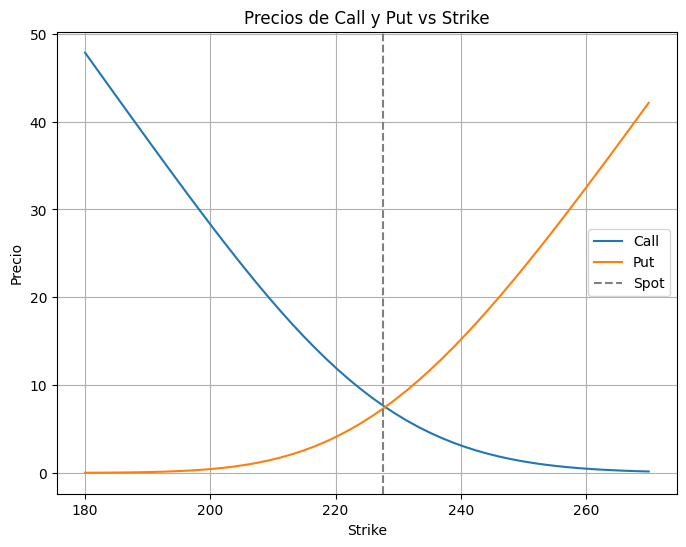

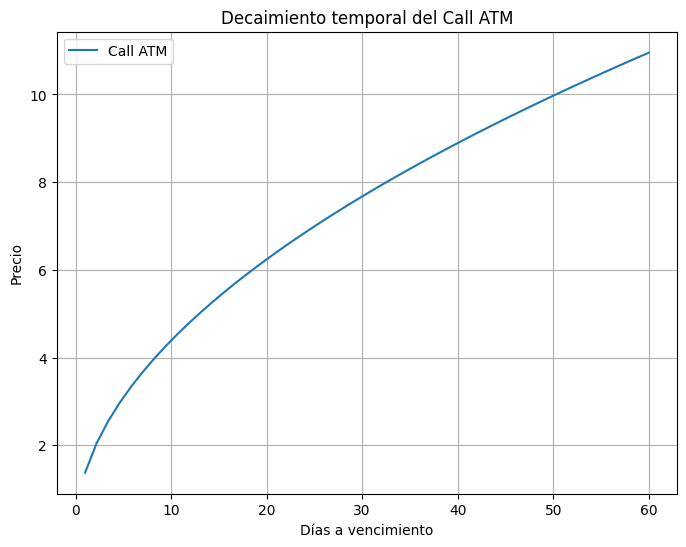

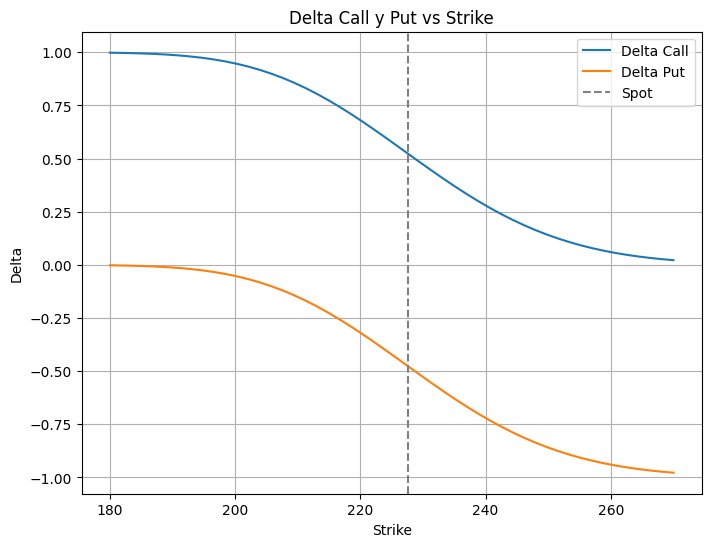

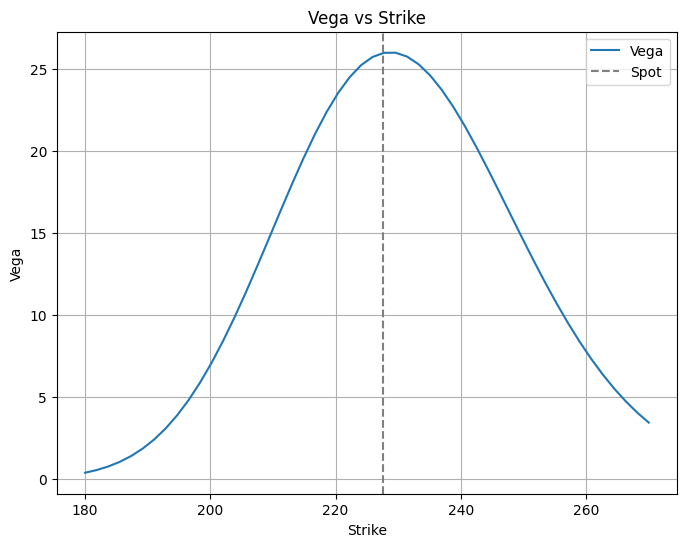

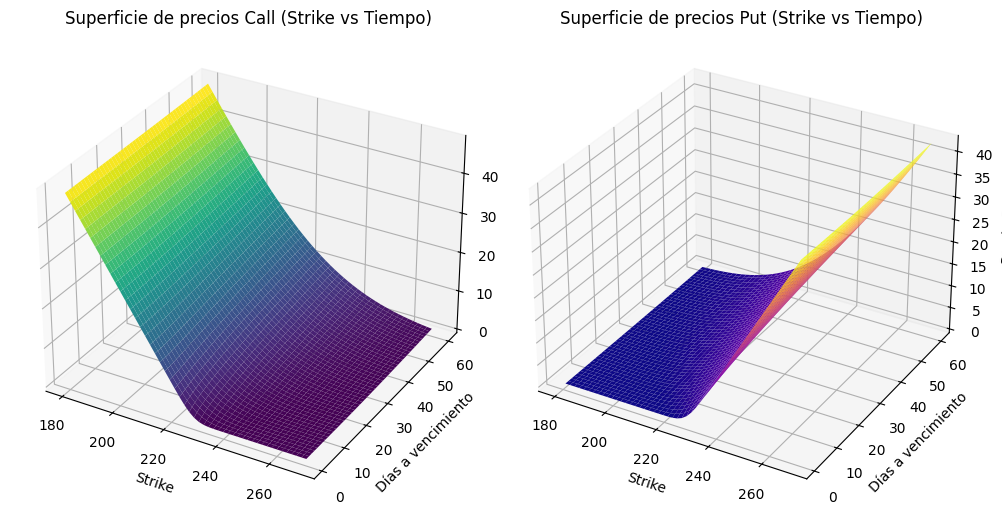

In [2]:
# Parámetros (ejemplo realista)
S0 = 227.55   # Precio spot (ejemplo: acción SAP en EUR)
sigma = 0.2879  # Volatilidad anualizada (28.79%)
r = 0.02        # Tasa libre de riesgo (2%)
T = 30 / 365    # Tiempo a vencimiento en años (30 días)

# Rango de strikes y tiempos
K_range = np.linspace(180, 270, 50)
T_range = np.linspace(1/365, 60/365, 50)

# Precios Call y Put vs Strike
calls = [black_scholes_call(S0, K, T, r, sigma) for K in K_range]
puts = [black_scholes_put(S0, K, T, r, sigma) for K in K_range]

plt.figure(figsize=(8,6))
plt.plot(K_range, calls, label="Call")
plt.plot(K_range, puts, label="Put")
plt.axvline(S0, color="gray", linestyle="--", label="Spot")
plt.title("Precios de Call y Put vs Strike")
plt.xlabel("Strike")
plt.ylabel("Precio")
plt.legend()
plt.grid(True)
plt.show()

# Decaimiento temporal del Call ATM
calls_T = [black_scholes_call(S0, S0, t, r, sigma) for t in T_range]
plt.figure(figsize=(8,6))
plt.plot(T_range*365, calls_T, label="Call ATM")
plt.title("Decaimiento temporal del Call ATM")
plt.xlabel("Días a vencimiento")
plt.ylabel("Precio")
plt.grid(True)
plt.legend()
plt.show()

# Delta Call y Put vs Strike
deltas_call = [delta_call(S0, K, T, r, sigma) for K in K_range]
deltas_put = [delta_put(S0, K, T, r, sigma) for K in K_range]
plt.figure(figsize=(8,6))
plt.plot(K_range, deltas_call, label="Delta Call")
plt.plot(K_range, deltas_put, label="Delta Put")
plt.axvline(S0, color="gray", linestyle="--", label="Spot")
plt.title("Delta Call y Put vs Strike")
plt.xlabel("Strike")
plt.ylabel("Delta")
plt.legend()
plt.grid(True)
plt.show()

# Vega vs Strike
vegas = [vega(S0, K, T, r, sigma) for K in K_range]
plt.figure(figsize=(8,6))
plt.plot(K_range, vegas, label="Vega")
plt.axvline(S0, color="gray", linestyle="--", label="Spot")
plt.title("Vega vs Strike")
plt.xlabel("Strike")
plt.ylabel("Vega")
plt.legend()
plt.grid(True)
plt.show()

# Superficies 3D Call y Put
K_grid, T_grid = np.meshgrid(K_range, T_range)
Z_call = np.zeros_like(K_grid)
Z_put = np.zeros_like(K_grid)
for i in range(len(T_range)):
    for j in range(len(K_range)):
        Z_call[i,j] = black_scholes_call(S0, K_grid[i,j], T_grid[i,j], r, sigma)
        Z_put[i,j] = black_scholes_put(S0, K_grid[i,j], T_grid[i,j], r, sigma)

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(121, projection="3d")
ax.plot_surface(K_grid, T_grid*365, Z_call, cmap="viridis")
ax.set_title("Superficie de precios Call (Strike vs Tiempo)")
ax.set_xlabel("Strike")
ax.set_ylabel("Días a vencimiento")
ax.set_zlabel("Precio Call")

ax2 = fig.add_subplot(122, projection="3d")
ax2.plot_surface(K_grid, T_grid*365, Z_put, cmap="plasma")
ax2.set_title("Superficie de precios Put (Strike vs Tiempo)")
ax2.set_xlabel("Strike")
ax2.set_ylabel("Días a vencimiento")
ax2.set_zlabel("Precio Put")
plt.tight_layout()
plt.show()


## 5. Conclusiones

- El modelo de **Black–Scholes** proporciona precios teóricos para opciones europeas, 
  así como sus sensibilidades ("griegas").  
- **Delta** indica cómo cambia la prima de la opción con el subyacente.  
- **Vega** muestra la importancia de la volatilidad, siendo máxima en ATM.  
- **Theta** refleja la pérdida de valor temporal, que se acelera cerca del vencimiento.  
- Los gráficos permiten visualizar intuitivamente cómo se comportan las opciones 
  respecto a $K$, $T$, $\sigma$ y $S_0$.  
- Comprender estas relaciones es fundamental para diseñar estrategias de cobertura 
  y especulación en mercados financieros.  

